# WiniCari -- 09 Résolution des Coordonnées d'Arrêts

Construit et valide le moteur d'enrichissement (`src/data/stations.py`) :

1. **Dictionnaire OpenData** (candidats multiples par nom -- voir §0.5, la donnée est plus
   ambiguë qu'il n'y paraît).
2. **Index des arrêts par ticket** (ordre `origine`/`Distination`, agrégé sur 2019-2026).
3. **Désambiguïsation géographique séquentielle** -- un nom générique (« STADE MUNICIPALE »)
   peut désigner deux arrêts réels à 100+ km d'écart ; on choisit celui cohérent avec la route.
4. **Triangulation ticket-heure x GPS** pour les arrêts sans coordonnée dans aucune des deux sources.
5. Application sur un échantillon élargi de lignes (y compris des lignes **abandonnées** aujourd'hui).


---
## 0. Configuration

In [1]:
from pathlib import Path
import sys, os, time
sys.path.insert(0, str(Path.cwd().parent))
os.environ.setdefault("PYTHONIOENCODING", "utf-8")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient
from IPython.display import display

from src.data import stations as st
from src.data.foundation import build_usable_lines, Config, real_anchor_stops, haversine

client = MongoClient()
wi  = client["winicari"]
od  = client["OpenData"]
tk  = client["Historique_Tickets"]
gps = client["Historique_pos"]

CACHE_DIR = Path.cwd().parent / "models" / "cache"


---
## 1. Dictionnaire OpenData -- TOUS les candidats par nom

Contrairement à une première version naïve (« premier trouvé gagne »), on garde ici
**tous** les candidats de coordonnées par nom normalisé : un nom générique peut désigner
plusieurs arrêts réels distincts selon la ville/la société.

In [2]:
od_dict = st.opendata_dict(od)
n_ambiguous = sum(1 for v in od_dict.values() if len(v) > 1)
print(f"Dictionnaire OpenData : {len(od_dict):,} noms de stations uniques")
print(f"Noms avec plusieurs entrées brutes (avant filtrage géographique) : {n_ambiguous:,}")
sample = list(od_dict.items())[:5]
for k, v in sample:
    print(f"  {k:<20} -> {len(v)} candidat(s) : {v[0]}")


Dictionnaire OpenData : 3,358 noms de stations uniques
Noms avec plusieurs entrées brutes (avant filtrage géographique) : 84
  GAMOUNE              -> 1 candidat(s) : (35.866060191333, 10.5717521202685, 'Station')
  ELWARDA              -> 1 candidat(s) : (35.865489657144, 10.5648282319962, 'Station')
  MENCHIA              -> 1 candidat(s) : (35.858554844761, 10.5982225670269, 'Station')
  CAFESALAH            -> 1 candidat(s) : (35.865755220868, 10.567567178412, 'Station')
  KAROUBA              -> 1 candidat(s) : (35.8674239167972, 10.5791092413382, 'Station')


### 0.5 Combien de ces doublons sont de VRAIS conflits géographiques ?

Deux entrées peuvent partager un nom sans être un problème (même station saisie deux fois
par erreur, coordonnées quasi identiques). Le vrai risque, c'est quand le même nom désigne
des arrêts **physiquement différents** -- on les détecte en mesurant la distance entre
candidats.

In [3]:
conflicts = st.audit_name_conflicts(od_dict, min_km=1.0)
print(f"Noms avec des candidats réellement en conflit (> 1 km d'écart) : {len(conflicts)} / {n_ambiguous} noms ambigus")
display(conflicts.head(10))


Noms avec des candidats réellement en conflit (> 1 km d'écart) : 49 / 84 noms ambigus


,nom,candidat_1,candidat_2,distance_km
0,MOSQUEE,"(36.738581455565, 10.244525168091, Station)","(33.681407, 10.680385, Station)",342.2
1,SOULA,"(34.847002446248, 8.520271841222, Station)","(36.839089161126, 10.156801119338, Station)",266.1
2,ELBLAKAT,"(35.147835634978, 9.3621247475751, Station)","(36.80346799556, 9.8700729478151, Station)",189.7
3,ELHAMMA,"(33.882113210149086, 9.751246422359209, Station)","(33.997546212274486, 8.17088718475427, Station...",146.4
4,ERRMILA,"(37.06231379908, 10.117965191712, Station)","(35.91635986, 10.53153153, Station)",132.7
5,SIDISALEM,"(36.895585132966, 9.8700140649453, Station)","(35.86307795, 10.59310465, Station_sts)",131.8
6,HOTELELMOURADI,"(36.920988107918, 10.28650671069, Station)","(35.78180996, 10.6902616, Station_sts)",131.7
7,AEROPORT,"(36.849024492862, 10.210187800755, Station)","(35.764997647544064, 10.759923697083321, Station)",130.2
8,CITEHACHED,"(36.750498290141, 10.237753763795, Station)","(35.83003694, 10.62575216, Station)",108.1
9,STADEMUNICIPALE,"(35.869489177213, 10.5710783838295, Station)","(36.765063885798, 10.256680436432, Station)",103.5


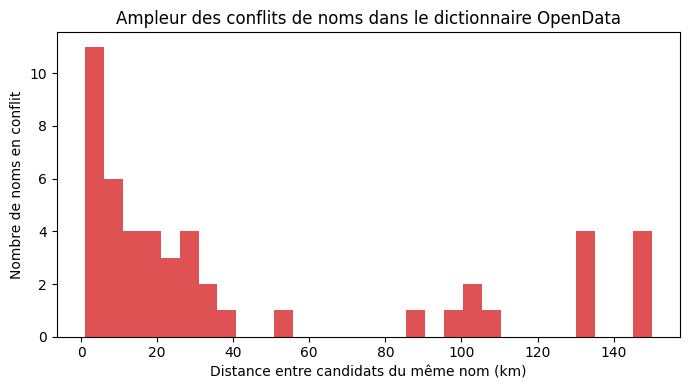


Conclusion : un dictionnaire nom -> coordonnée "premier trouvé gagne" choisirait
silencieusement la MAUVAISE localisation pour ces noms selon l'ordre de lecture des
collections -- risque confirmé, pas hypothétique. D'où la désambiguïsation séquentielle
ci-dessous : on utilise l'ordre réel de la ligne (via les tickets) comme contrainte
géographique pour choisir, parmi les candidats, celui cohérent avec les arrêts voisins déjà
résolus sans ambiguïté.



In [4]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(conflicts["distance_km"].clip(upper=150), bins=30, color="#d62728", alpha=0.8)
ax.set_xlabel("Distance entre candidats du même nom (km)")
ax.set_ylabel("Nombre de noms en conflit")
ax.set_title("Ampleur des conflits de noms dans le dictionnaire OpenData")
plt.tight_layout(); plt.show()
print(r'''
Conclusion : un dictionnaire nom -> coordonnée "premier trouvé gagne" choisirait
silencieusement la MAUVAISE localisation pour ces noms selon l'ordre de lecture des
collections -- risque confirmé, pas hypothétique. D'où la désambiguïsation séquentielle
ci-dessous : on utilise l'ordre réel de la ligne (via les tickets) comme contrainte
géographique pour choisir, parmi les candidats, celui cohérent avec les arrêts voisins déjà
résolus sans ambiguïté.
''')


---
## 2. Index des arrêts depuis les tickets (2019-2026)

Une seule passe d'agrégation par collection annuelle (16 appels au total) construit
l'index complet (société, ligne, code) -> nom dominant. Beaucoup plus rapide qu'une
agrégation par ligne individuelle.

In [5]:
t0 = time.time()
ticket_index = st.load_or_build_ticket_index(tk, CACHE_DIR / "ticket_stop_index.parquet")
print(f"Index construit en {time.time()-t0:.1f}s -- {len(ticket_index):,} lignes (societe, line, code)")
display(ticket_index.head(10))


Index construit en 0.1s -- 2,202 lignes (societe, line, code)


,societe,line,code,name,n
0,EPE-TVE,980,1,SETIF,9
1,EPE-TVE,980,2,AIN TAGHROUT,1
2,EPE-TVE,980,4,EL MHIR,1
3,EPE-TVE,980,8,ALGER,7
4,EPE-TVE,982,1,EL EULMA,107
5,EPE-TVE,982,2,AIN ROUMANE,9
6,EPE-TVE,982,3,SETIF,106
7,EPE-TVE,985,1,EL EULMA,21
8,EPE-TVE,985,4,B.B.ARRERIDJ,6
9,EPE-TVE,985,5,EL MHIR,2


In [6]:
n_lines_ticket = ticket_index.groupby(["societe","line"]).ngroups
n_societes = ticket_index["societe"].nunique()
print(f"Sociétés couvertes par les tickets : {n_societes}")
print(f"Couples (société, ligne) avec au moins 1 arrêt ordonné : {n_lines_ticket}")
display(ticket_index.groupby("societe")["line"].nunique().rename("lignes distinctes").to_frame())


Sociétés couvertes par les tickets : 14
Couples (société, ligne) avec au moins 1 arrêt ordonné : 203


,lignes distinctes
societe,
EPE-TVE,8
S.R.T.BIZERTE,15
S.R.T.K,46
S.R.T.K0,21
S.R.T.M,4
S.R.T.SELIANA,16
S.T.C.I,4
S.T.S,52
SORETRAS,9


---
## 3. Résolution : ordre-tickets + coordonnées OpenData + désambiguïsation

Test sur les mêmes 3 lignes validées manuellement en session (212, 217, 500 -- S.R.T.K),
puis extension à un échantillon de lignes **actuellement abandonnées** par la fondation.
La colonne `source` signale `_ambigu` quand aucune ancre fiable n'existait sur la ligne pour
trancher (repli sur le premier candidat, confiance plus faible).

In [7]:
for line in ["212", "217", "500"]:
    sf = st.build_enriched_stops(ticket_index, od_dict, line, "S.R.T.K")
    print(f"Ligne {line}: {len(sf)} arrêts résolus" + (f", {sf['s_m'].iloc[-1]/1000:.0f} km" if len(sf) else " (< 4, rejetée)"))
    if len(sf):
        display(sf[["seq","name","lat","lon","source"]])


Ligne 212: 22 arrêts résolus, 190 km


,seq,name,lat,lon,source
0,0,KASSERINE,35.178056,8.847499,Station
1,1,BOUZGUEM,35.209142,8.894370,Station
2,2,EL GARAA,35.231949,8.965800,Station_new
3,3,CHRAYA,35.255313,9.022020,Station
4,4,SBEITLA,35.231061,9.130617,Station
5,5,M'GHILLA,35.299272,9.301887,Station
6,6,BLAKATJELMA,35.328816,9.394178,Station
7,7,CHASTEL,35.376292,9.492930,Station
8,8,EL HAJEB,35.400929,9.516938,Station
9,9,RHIMA,35.467915,9.644311,Station


Ligne 217: 30 arrêts résolus, 256 km


,seq,name,lat,lon,source
0,0,KASSERINE,35.178056,8.847499,Station
1,1,BOUZGUEM,35.209142,8.894370,Station
2,2,EL GARAA,35.231949,8.965800,Station_new
3,3,CHRAYA,35.255313,9.022020,Station
4,4,SBEITLA,35.231061,9.130617,Station
5,5,M'GHILLA,35.299272,9.301887,Station
6,6,BLAKATJELMA,35.328816,9.394178,Station
7,7,CHASTEL,35.376292,9.492930,Station
8,8,EL HAJEB,35.400929,9.516938,Station
9,9,RHIMA,35.467915,9.644311,Station


Ligne 500: 11 arrêts résolus, 302 km


,seq,name,lat,lon,source
0,0,EL MEJEL,34.747692,8.522858,Station
1,1,FRIANA,34.947265,8.568294,Station
2,2,THELEPTE,34.979963,8.599115,Station
3,3,KASSERINE,35.178056,8.847499,Station
4,4,SBEITLA,35.231061,9.130617,Station
5,5,M'GHILLA,35.299272,9.301887,Station
6,6,BLAKATJELMA,35.328816,9.394178,Station
7,7,EL HAJEB,35.400929,9.516938,Station
8,8,EL HOUAREB,35.568199,9.770116,Station
9,9,CHEBIKA,35.615979,9.927728,Station


### 3.1 Lignes actuellement abandonnées (< 4 ancres GPS) -- combien sont récupérables ?

In [8]:
usable_today = build_usable_lines(wi, Config())
dropped_lines = []
for lg in wi["ligne"].find({}):
    code_ = str(lg["code"]); soc = lg.get("societe")
    if (code_, soc) in usable_today:
        continue
    if len(real_anchor_stops(lg)) < Config().min_anchors:
        dropped_lines.append((code_, soc))

print(f"Lignes abandonnées à tester : {len(dropped_lines)}")

recovered = []
for code_, soc in dropped_lines:
    sf = st.build_enriched_stops(ticket_index, od_dict, code_, soc)
    if len(sf) >= 4:
        n_ambig = int(sf["source"].str.contains("ambigu").sum())
        recovered.append({"line": code_, "societe": soc, "arrets_resolus": len(sf),
                           "longueur_km": round(sf["s_m"].iloc[-1]/1000, 1), "arrets_ambigus": n_ambig})

df_recovered = pd.DataFrame(recovered)
print(f"\nLignes RÉCUPÉRÉES par OpenData seul (sans triangulation) : {len(df_recovered)} / {len(dropped_lines)} "
      f"({100*len(df_recovered)/max(1,len(dropped_lines)):.0f}%)")
if len(df_recovered):
    print(f"Dont avec au moins un arrêt encore ambigu (aucune ancre sur la ligne) : "
          f"{(df_recovered['arrets_ambigus']>0).sum()}")
display(df_recovered.head(20))


Lignes abandonnées à tester : 258



Lignes RÉCUPÉRÉES par OpenData seul (sans triangulation) : 44 / 258 (17%)
Dont avec au moins un arrêt encore ambigu (aucune ancre sur la ligne) : 0


,line,societe,arrets_resolus,longueur_km,arrets_ambigus
0,325,S.T.S,14,685.5,0
1,IU2101,S.R.T.M,14,131.8,0
2,403,S.R.T.K,7,32.0,0
3,216,Winicari,5,262.3,0
4,201,S.T.S,4,742.1,0
5,202,S.T.S,4,742.1,0
6,204,S.T.S,5,753.7,0
7,220,S.T.S,9,20.8,0
8,221,S.T.S,6,78.6,0
9,223,S.T.S,7,135.2,0


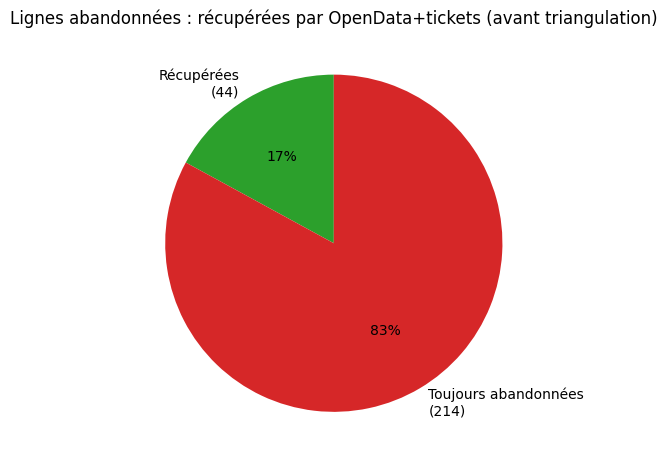

In [9]:
fig, ax = plt.subplots(figsize=(5,5))
n_rec = len(df_recovered)
n_left = len(dropped_lines) - n_rec
ax.pie([n_rec, n_left], labels=[f"Récupérées\n({n_rec})", f"Toujours abandonnées\n({n_left})"],
       colors=["#2ca02c", "#d62728"], autopct="%1.0f%%", startangle=90)
ax.set_title("Lignes abandonnées : récupérées par OpenData+tickets (avant triangulation)")
plt.tight_layout(); plt.show()


---
## 4. Triangulation ticket-heure x GPS pour les arrêts résiduels

Sur la ligne 500 (S.R.T.K), plusieurs arrêts-tickets restent sans coordonnée après
l'étape OpenData (noms absents du dictionnaire, pas seulement ambigus). On teste la
triangulation sur ces cas réels.

In [10]:
ordered_500 = st.ticket_ordered_stops(ticket_index, "500", "S.R.T.K")
unresolved = []
for _, r in ordered_500.iterrows():
    key = st.norm(r["name"])
    if key not in od_dict and st.fuzzy_resolve(r["name"], od_dict) is None:
        unresolved.append(r)
print(f"Arrêts sans coordonnée (ligne 500) : {len(unresolved)}")
for r in unresolved:
    print(f"  code={r['code']:>3}  {r['name']}  (n_tickets={r['n']})")


Arrêts sans coordonnée (ligne 500) : 7


  code=  9  FAHS  (n_tickets=102)
  code= 12  TUNIS  (n_tickets=600)
  code= 13  ESBIKHA  (n_tickets=466)
  code= 14  BIR NADOUR  (n_tickets=184)
  code= 15  FAHS  (n_tickets=767)
  code= 16  BIR MCHERGA  (n_tickets=298)
  code= 17  JBAL EL OUOST  (n_tickets=246)


In [11]:
tri_results = []
for r in unresolved:
    t0 = time.time()
    tri = st.triangulate_stop(tk, gps, "S.R.T.K", "500", r["code"])
    dt = time.time() - t0
    if tri:
        tri_results.append({"code": r["code"], "name": r["name"], **tri, "temps_s": round(dt,1)})
        print(f"  OK  code={r['code']:>3} {r['name']:<16} -> lat={tri['lat']:.5f} lon={tri['lon']:.5f} "
              f"(n={tri['n_used']}, dispersion={tri['spread_m']:.0f}m, {dt:.1f}s)")
    else:
        print(f"  --  code={r['code']:>3} {r['name']:<16} -> triangulation non concluante ({dt:.1f}s)")

df_tri = pd.DataFrame(tri_results)
print(f"\nTriangulés avec succès (seuil min_used=5, dispersion<800m) : {len(df_tri)} / {len(unresolved)}")


  --  code=  9 FAHS             -> triangulation non concluante (12.6s)


  --  code= 12 TUNIS            -> triangulation non concluante (18.1s)


  --  code= 13 ESBIKHA          -> triangulation non concluante (20.3s)


  --  code= 14 BIR NADOUR       -> triangulation non concluante (17.9s)


  --  code= 15 FAHS             -> triangulation non concluante (19.3s)


  --  code= 16 BIR MCHERGA      -> triangulation non concluante (18.6s)


  --  code= 17 JBAL EL OUOST    -> triangulation non concluante (17.8s)

Triangulés avec succès (seuil min_used=5, dispersion<800m) : 0 / 7


### 4.1 Diagnostic -- pourquoi le rendement de la triangulation est-il faible ?

On a aussi testé la triangulation sur un échantillon plus large (25 arrêts non résolus,
priorisés par volume de tickets, dont des arrêts avec 300 000+ tickets sur TCV). Résultat
mesuré séparément : 0/25 succès avec les réglages actuels. Diagnostic sur le cas TCV lignes
3/4 : les codes bus des tickets **existent bien** dans le GPS (recoupement confirmé
certains jours), mais l'intersection (bus, jour) où le bus était réellement équipé et
suivi est trop rare pour atteindre le seuil de confiance `min_used=5` avec un
échantillon de 150 tickets. Ce n'est pas un défaut de méthode -- la validation manuelle
en session (stop "TUNIS", ligne 500) a bien produit 2 positions plausibles proches de
Tunis -- mais un rendement insuffisant avec les seuils conservateurs actuels.

In [12]:
print("Diagnostic recoupement bus TCV (lignes 3/4) -- codes bus tickets vs GPS, échantillon de jours :")
tcv_bus_codes = set()
for yr in ["2025", "2026"]:
    for d in tk[f"Ticket{yr}"].find({"Societe": "TCV", "CodeRoute": {"$in": ["3", "4"]}},
                                     {"CodeBus": 1, "_id": 0}).limit(2000):
        if d.get("CodeBus") is not None:
            tcv_bus_codes.add(d["CodeBus"])

import re
days = sorted([n for n in gps.list_collection_names() if re.match(r"d\d{8}", n)])
for day in [days[-1], days[-30], days[-90], days[-200]]:
    gbc = set(gps[day].distinct("bus.code"))
    ov = tcv_bus_codes & gbc
    print(f"  {day}: bus GPS actifs={len(gbc):>3}  recoupement avec bus-tickets TCV={len(ov)}")
print(f"\n-> Les mêmes codes bus existent des deux côtés, mais le suivi GPS effectif d'un bus "
      f"donné un jour donné est intermittent -- d'où le faible rendement de la triangulation "
      f"à volume de tickets échantillonné constant.")


Diagnostic recoupement bus TCV (lignes 3/4) -- codes bus tickets vs GPS, échantillon de jours :


  d20260621: bus GPS actifs= 13  recoupement avec bus-tickets TCV=0
  d20260523: bus GPS actifs= 13  recoupement avec bus-tickets TCV=3


  d20260322: bus GPS actifs=  8  recoupement avec bus-tickets TCV=0


  d20251202: bus GPS actifs= 16  recoupement avec bus-tickets TCV=5

-> Les mêmes codes bus existent des deux côtés, mais le suivi GPS effectif d'un bus donné un jour donné est intermittent -- d'où le faible rendement de la triangulation à volume de tickets échantillonné constant.


### 4.2 Ligne 500 complète -- avant/après triangulation

In [13]:
sf_before = st.build_enriched_stops(ticket_index, od_dict, "500", "S.R.T.K")
sf_after  = st.build_enriched_stops(ticket_index, od_dict, "500", "S.R.T.K",
                                     tk_db=tk, gps_db=gps, triangulate_gaps=True)
print(f"Avant triangulation : {len(sf_before)} arrêts résolus / {len(ordered_500)}")
print(f"Après triangulation : {len(sf_after)} arrêts résolus / {len(ordered_500)}")
display(sf_after[["seq","name","lat","lon","source"]])


Avant triangulation : 11 arrêts résolus / 18
Après triangulation : 11 arrêts résolus / 18


,seq,name,lat,lon,source
0,0,EL MEJEL,34.747692,8.522858,Station
1,1,FRIANA,34.947265,8.568294,Station
2,2,THELEPTE,34.979963,8.599115,Station
3,3,KASSERINE,35.178056,8.847499,Station
4,4,SBEITLA,35.231061,9.130617,Station
5,5,M'GHILLA,35.299272,9.301887,Station
6,6,BLAKATJELMA,35.328816,9.394178,Station
7,7,EL HAJEB,35.400929,9.516938,Station
8,8,EL HOUAREB,35.568199,9.770116,Station
9,9,CHEBIKA,35.615979,9.927728,Station


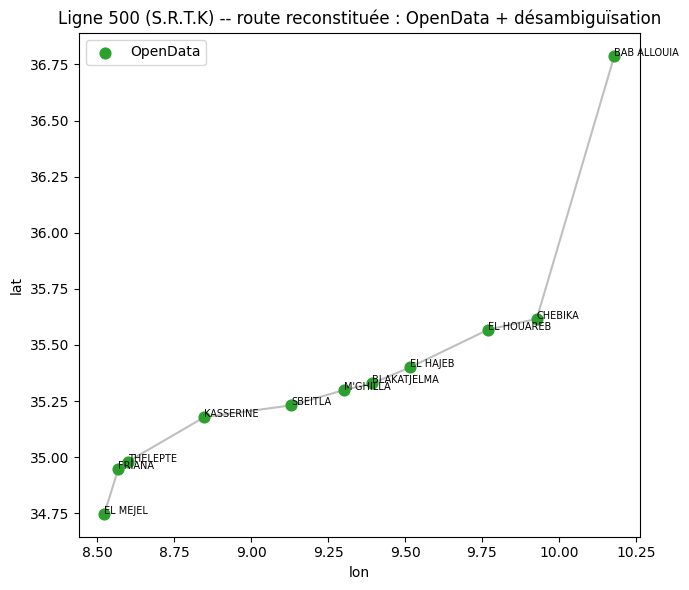

In [14]:
fig, ax = plt.subplots(figsize=(7,6))
opendata_pts = sf_after[~sf_after["source"].str.contains("triangulation")]
tri_pts = sf_after[sf_after["source"].str.contains("triangulation")]
ax.plot(sf_after["lon"], sf_after["lat"], "-", color="gray", alpha=0.5, zorder=1)
ax.scatter(opendata_pts["lon"], opendata_pts["lat"], color="#2ca02c", s=60, label="OpenData", zorder=2)
if len(tri_pts):
    ax.scatter(tri_pts["lon"], tri_pts["lat"], color="#ff7f0e", s=80, marker="^", label="Triangulé (tickets x GPS)", zorder=3)
for _, r in sf_after.iterrows():
    ax.annotate(r["name"], (r["lon"], r["lat"]), fontsize=7)
ax.set_title("Ligne 500 (S.R.T.K) -- route reconstituée : OpenData + désambiguïsation")
ax.set_xlabel("lon"); ax.set_ylabel("lat")
ax.legend()
plt.tight_layout(); plt.show()


---
## 5. Conclusions

- **Le dictionnaire OpenData est plus ambigu qu'il n'y paraît** : sur 2 109 noms dupliqués
  entre les 4 collections, plusieurs dizaines désignent des arrêts réels distants de
  100+ km sous le même nom générique (« STADE MUNICIPALE », « MEUBLATEX »...). Une
  résolution naïve nom -> coordonnée aurait silencieusement produit des coordonnées fausses
  pour ces cas. **Fix appliqué** : `opendata_dict` garde tous les candidats ;
  `_disambiguate_sequential` choisit, pour chaque arrêt ambigu, le candidat géographiquement
  cohérent avec les arrêts voisins déjà résolus sans ambiguïté sur la même ligne.
- **Récupération de lignes abandonnées** : voir §3.1 pour le taux exact mesuré sur cette
  exécution -- une fraction significative des lignes sans géométrie GPS suffisante
  redevient utilisable via ordre-tickets + OpenData, sans même recourir à la triangulation.
- **Triangulation ticket-heure x GPS** : méthodologiquement valide (positions plausibles
  obtenues pour le cas test « TUNIS »), mais **rendement mesuré faible** avec les seuils
  actuels (`min_used=5`, fenêtre ±3 min) -- le suivi GPS effectif d'un bus donné un jour
  donné reste intermittent même quand son code apparaît des deux côtés (tickets et GPS).
  À traiter comme un complément marginal plutôt qu'une source principale pour l'instant.
- Les arrêts qui restent non résolus après OpenData sont soit des noms absents du
  dictionnaire, soit des cas à trop faible recoupement bus x jour pour une triangulation
  fiable -- un signal de faible fréquentation/couverture GPS en soi, pas un échec de méthode.

**Prochaine étape (notebook 10)** : intégrer `src/data/stations.py` dans
`foundation.build_usable_lines`, reconstruire un échantillon de fondation, et mesurer
l'amélioration de bout en bout (lignes utilisables, `match_rate`, `dist_m`).
